# Representation Learning With PCA and Autoencoders

This notebook solves the assignment tasks for MNIST and CIFAR10 converted to gray level.

Requirements implemented:

- MNIST and CIFAR10 loaded from `tensorflow.keras.datasets`
- CIFAR10 converted to gray level
- both datasets resized to 28 x 28
- intensities rescaled to [50, 200]
- random 70% / 20% / 10% train / validation / test split
- standard PCA and randomized PCA with 30 components
- logistic regression classification on PCA features and autoencoder features
- multiclass ROC curves
- reconstruction SNR in dB
- tied-weight linear autoencoder with unit-magnitude encoder vectors
- component/weight visualization and quantitative PCA-AE comparison
- deep convolutional autoencoder with 30-dimensional latent space
- single hidden layer and three hidden layer dense autoencoder comparisons

Before running:

```python
# Uncomment if your environment is missing packages.
# %pip install -q tensorflow scikit-learn matplotlib pandas seaborn
```



In [2]:
import os
import socket
import random
from datetime import datetime
import warnings
from dataclasses import dataclass

# Keep Matplotlib cache inside a writable location when running from managed kernels.
os.environ.setdefault("MPLCONFIGDIR", os.path.join("/tmp", "matplotlib"))
os.makedirs(os.environ["MPLCONFIGDIR"], exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

import sklearn
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    roc_curve,
    auc,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize, StandardScaler

from scipy.optimize import linear_sum_assignment

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")



I0000 00:00:1780920594.591235   62035 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1780920594.800606   62035 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1780920595.549576   62035 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


## Configuration

`FAST_MODE=False` runs the full 70/20/10 split required by the assignment.
If you only want to verify that the notebook executes, set `FAST_MODE=True`.



In [3]:
RANDOM_SEED = 42
FAST_MODE = False

N_COMPONENTS = 30
IMAGE_SHAPE = (28, 28)
N_CLASSES = 10

BATCH_SIZE = 256
LINEAR_AE_EPOCHS = 150
DENSE_AE_EPOCHS = 60
CONV_AE_EPOCHS = 50
PATIENCE = 12

if FAST_MODE:
    # Small values for quick testing only. Leave FAST_MODE=False for submission runs.
    MAX_TOTAL_PER_DATASET = 12000
    LINEAR_AE_EPOCHS = 10
    DENSE_AE_EPOCHS = 8
    CONV_AE_EPOCHS = 8
else:
    MAX_TOTAL_PER_DATASET = None

np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

print("TensorFlow:", tf.__version__)
print("scikit-learn:", sklearn.__version__)
print("FAST_MODE:", FAST_MODE)
gpus = tf.config.list_physical_devices("GPU")
print("GPU devices:", gpus)
for gpu in gpus:
    details = tf.config.experimental.get_device_details(gpu)
    print("GPU name:", details.get("device_name", "unknown"))
print("Hostname:", socket.gethostname())
print("Date/Time:", datetime.now().strftime("%Y-%m-%d %H:%M:%S"))


TensorFlow: 2.21.0
scikit-learn: 1.8.0
FAST_MODE: False
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
GPU name: NVIDIA GeForce RTX 4060 Ti
Hostname: ubuntu-client.tss.com
Date/Time: 2026-06-08 17:40:00


## Helper Functions



In [3]:
@dataclass
class DatasetSplit:
    name: str
    x_train_img_50_200: np.ndarray
    y_train: np.ndarray
    x_val_img_50_200: np.ndarray
    y_val: np.ndarray
    x_test_img_50_200: np.ndarray
    y_test: np.ndarray

    @property
    def x_train_flat_50_200(self):
        return self.x_train_img_50_200.reshape(len(self.x_train_img_50_200), -1)

    @property
    def x_val_flat_50_200(self):
        return self.x_val_img_50_200.reshape(len(self.x_val_img_50_200), -1)

    @property
    def x_test_flat_50_200(self):
        return self.x_test_img_50_200.reshape(len(self.x_test_img_50_200), -1)

    @property
    def x_train_01(self):
        return (self.x_train_img_50_200 - 50.0) / 150.0

    @property
    def x_val_01(self):
        return (self.x_val_img_50_200 - 50.0) / 150.0

    @property
    def x_test_01(self):
        return (self.x_test_img_50_200 - 50.0) / 150.0

    @property
    def x_train_flat_01(self):
        return self.x_train_01.reshape(len(self.x_train_01), -1)

    @property
    def x_val_flat_01(self):
        return self.x_val_01.reshape(len(self.x_val_01), -1)

    @property
    def x_test_flat_01(self):
        return self.x_test_01.reshape(len(self.x_test_01), -1)


def set_all_seeds(seed=RANDOM_SEED):
    np.random.seed(seed)
    random.seed(seed)
    tf.random.set_seed(seed)


def to_50_200(x):
    """Map image intensities from [0, 255] to [50, 200]."""
    x = x.astype("float32")
    return 50.0 + (x / 255.0) * 150.0


def preprocess_mnist_images(x):
    x = x.astype("float32")
    if x.ndim == 3:
        x = x[..., np.newaxis]
    # MNIST is already 28 x 28; keep this call for a consistent pipeline.
    x = tf.image.resize(x, IMAGE_SHAPE, method="bilinear").numpy()
    return to_50_200(x)


def preprocess_cifar10_images(x):
    x = x.astype("float32")
    # ITU-R BT.601 luminance conversion.
    gray = 0.299 * x[..., 0] + 0.587 * x[..., 1] + 0.114 * x[..., 2]
    gray = gray[..., np.newaxis]
    gray = tf.image.resize(gray, IMAGE_SHAPE, method="bilinear").numpy()
    return to_50_200(gray)


def make_split(name, x, y, max_total=None):
    y = y.reshape(-1).astype("int64")

    if max_total is not None and max_total < len(x):
        rng = np.random.default_rng(RANDOM_SEED)
        idx = rng.choice(len(x), size=max_total, replace=False)
        x = x[idx]
        y = y[idx]

    # First split off 10% test, then split the remaining 90% into 70/20.
    x_temp, x_test, y_temp, y_test = train_test_split(
        x,
        y,
        test_size=0.10,
        random_state=RANDOM_SEED,
        stratify=y,
    )
    val_fraction_of_temp = 0.20 / 0.90
    x_train, x_val, y_train, y_val = train_test_split(
        x_temp,
        y_temp,
        test_size=val_fraction_of_temp,
        random_state=RANDOM_SEED,
        stratify=y_temp,
    )

    return DatasetSplit(name, x_train, y_train, x_val, y_val, x_test, y_test)


def mean_snr_db(original, reconstructed, eps=1e-10):
    """Average per-image SNR in dB: 10 log10(signal_power / noise_power)."""
    original = original.reshape(len(original), -1).astype("float64")
    reconstructed = reconstructed.reshape(len(reconstructed), -1).astype("float64")
    signal_power = np.mean(original**2, axis=1)
    noise_power = np.mean((original - reconstructed) ** 2, axis=1)
    return float(np.mean(10.0 * np.log10((signal_power + eps) / (noise_power + eps))))


def plot_component_grid(components, title, n_rows=5, n_cols=6, image_shape=IMAGE_SHAPE, cmap="gray"):
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, 8))
    fig.suptitle(title, fontsize=15, y=0.98)
    for i, ax in enumerate(axes.ravel()):
        comp = components[i].reshape(image_shape)
        ax.imshow(comp, cmap=cmap)
        ax.set_title(f"{i + 1}", fontsize=8)
        ax.axis("off")
    plt.tight_layout()
    plt.show()


def plot_reconstruction_examples(original, reconstructed, title, n=8):
    original = original[:n].reshape(n, *IMAGE_SHAPE)
    reconstructed = reconstructed[:n].reshape(n, *IMAGE_SHAPE)
    fig, axes = plt.subplots(2, n, figsize=(1.7 * n, 3.6))
    fig.suptitle(title, fontsize=14)
    for i in range(n):
        axes[0, i].imshow(original[i], cmap="gray", vmin=50, vmax=200)
        axes[0, i].axis("off")
        axes[0, i].set_title("Test", fontsize=8)
        axes[1, i].imshow(reconstructed[i], cmap="gray", vmin=50, vmax=200)
        axes[1, i].axis("off")
        axes[1, i].set_title("Recon", fontsize=8)
    plt.tight_layout()
    plt.show()


def fit_logistic_and_roc(z_train, y_train, z_test, y_test, title):
    clf = LogisticRegression(
        max_iter=1500,
        solver="lbfgs",
        n_jobs=-1,
        random_state=RANDOM_SEED,
    )
    clf.fit(z_train, y_train)
    y_pred = clf.predict(z_test)
    y_score = clf.predict_proba(z_test)

    acc = accuracy_score(y_test, y_pred)
    macro_auc = roc_auc_score(y_test, y_score, multi_class="ovr", average="macro")

    y_test_bin = label_binarize(y_test, classes=np.arange(N_CLASSES))
    fpr = {}
    tpr = {}
    roc_auc = {}
    for class_id in range(N_CLASSES):
        fpr[class_id], tpr[class_id], _ = roc_curve(y_test_bin[:, class_id], y_score[:, class_id])
        roc_auc[class_id] = auc(fpr[class_id], tpr[class_id])

    plt.figure(figsize=(8, 6))
    for class_id in range(N_CLASSES):
        plt.plot(fpr[class_id], tpr[class_id], lw=1.2, label=f"Class {class_id} AUC={roc_auc[class_id]:.3f}")
    plt.plot([0, 1], [0, 1], "k--", lw=1)
    plt.xlabel("False positive rate")
    plt.ylabel("True positive rate")
    plt.title(f"{title}\nAccuracy={acc:.4f}, macro AUC={macro_auc:.4f}")
    plt.legend(fontsize=8, ncol=2)
    plt.tight_layout()
    plt.show()

    return clf, {"accuracy": acc, "macro_auc": macro_auc}


def compare_component_spaces(pca_components, ae_components, dataset_name):
    """Compare PCA components and AE weight vectors.

    Both inputs should have shape (n_components, n_pixels).
    Sign is ignored because eigenvectors are sign-ambiguous.
    """
    pca_norm = pca_components / np.linalg.norm(pca_components, axis=1, keepdims=True)
    ae_norm = ae_components / np.linalg.norm(ae_components, axis=1, keepdims=True)

    abs_cos = np.abs(pca_norm @ ae_norm.T)
    row_ind, col_ind = linear_sum_assignment(-abs_cos)
    matched = abs_cos[row_ind, col_ind]

    singular_values = np.linalg.svd(pca_norm @ ae_norm.T, compute_uv=False)
    principal_angles_deg = np.degrees(np.arccos(np.clip(singular_values, -1, 1)))

    summary = {
        "dataset": dataset_name,
        "mean_matched_abs_cosine": float(np.mean(matched)),
        "median_matched_abs_cosine": float(np.median(matched)),
        "min_matched_abs_cosine": float(np.min(matched)),
        "mean_subspace_singular_value": float(np.mean(singular_values)),
        "max_principal_angle_deg": float(np.max(principal_angles_deg)),
    }
    return summary, abs_cos, matched, principal_angles_deg


def make_reconstruction_dataset(x, training=False):
    ds = tf.data.Dataset.from_tensor_slices(x.astype("float32"))
    if training:
        ds = ds.shuffle(min(len(x), 10000), seed=RANDOM_SEED, reshuffle_each_iteration=True)
    return ds.batch(BATCH_SIZE).map(lambda batch: (batch, batch), num_parallel_calls=tf.data.AUTOTUNE).prefetch(tf.data.AUTOTUNE)


def make_input_dataset(x):
    return tf.data.Dataset.from_tensor_slices(x.astype("float32")).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)


def early_stopping():
    return keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=PATIENCE,
        restore_best_weights=True,
    )


def to_keras_images_01(x_01):
    return x_01.astype("float32")


def flat01_to_50_200(x_flat_01):
    x_flat_01 = np.clip(x_flat_01, 0.0, 1.0)
    return 50.0 + 150.0 * x_flat_01



## Load and Preprocess Datasets



In [4]:
print("Loading MNIST and CIFAR10 from Keras...")
(mnist_x_train_raw, mnist_y_train_raw), (mnist_x_test_raw, mnist_y_test_raw) = keras.datasets.mnist.load_data()
(cifar_x_train_raw, cifar_y_train_raw), (cifar_x_test_raw, cifar_y_test_raw) = keras.datasets.cifar10.load_data()

mnist_x_raw = np.concatenate([mnist_x_train_raw, mnist_x_test_raw], axis=0)
mnist_y_raw = np.concatenate([mnist_y_train_raw, mnist_y_test_raw], axis=0)
cifar_x_raw = np.concatenate([cifar_x_train_raw, cifar_x_test_raw], axis=0)
cifar_y_raw = np.concatenate([cifar_y_train_raw, cifar_y_test_raw], axis=0)

mnist_x = preprocess_mnist_images(mnist_x_raw)
cifar_x = preprocess_cifar10_images(cifar_x_raw)

mnist = make_split("MNIST", mnist_x, mnist_y_raw, max_total=MAX_TOTAL_PER_DATASET)
cifar10_gray = make_split("CIFAR10-gray", cifar_x, cifar_y_raw, max_total=MAX_TOTAL_PER_DATASET)
datasets = [mnist, cifar10_gray]

for ds in datasets:
    print(
        f"{ds.name}: train={len(ds.y_train)}, validation={len(ds.y_val)}, test={len(ds.y_test)}, "
        f"range=({ds.x_train_img_50_200.min():.1f}, {ds.x_train_img_50_200.max():.1f})"
    )



Loading MNIST and CIFAR10 from Keras...


I0000 00:00:1780577816.580871  430620 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13334 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Ti, pci bus id: 0000:01:00.0, compute capability: 8.9


MNIST: train=48999, validation=14001, test=7000, range=(50.0, 200.0)
CIFAR10-gray: train=42000, validation=12000, test=6000, range=(50.0, 200.0)


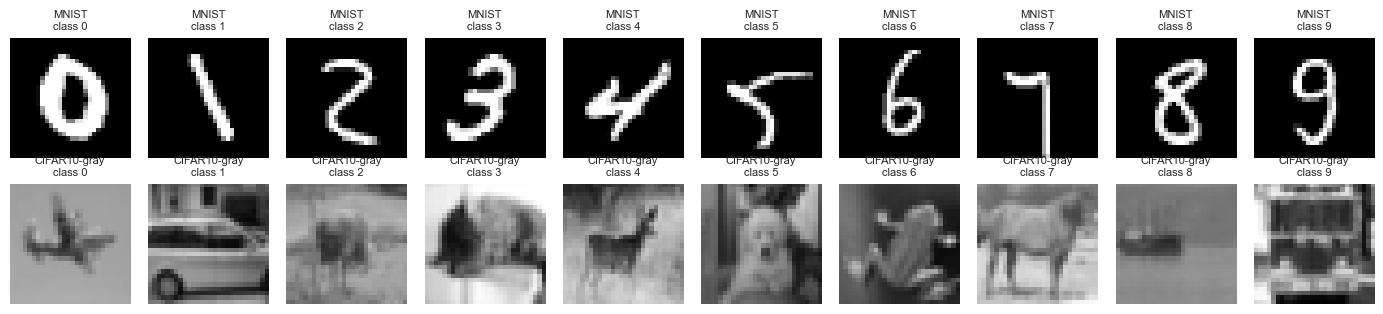

In [5]:
fig, axes = plt.subplots(2, 10, figsize=(14, 3.2))
for row, ds in enumerate(datasets):
    for col in range(10):
        idx = np.where(ds.y_train == col)[0][0]
        axes[row, col].imshow(ds.x_train_img_50_200[idx].squeeze(), cmap="gray", vmin=50, vmax=200)
        axes[row, col].set_title(f"{ds.name}\nclass {col}", fontsize=8)
        axes[row, col].axis("off")
plt.tight_layout()
plt.show()



# Task 1: Standard PCA, Randomized PCA, Logistic Regression, ROC and SNR

For each dataset, PCA is fitted using the 70% training split. The first 30 principal components are then used as
features for a multinomial logistic regression classifier. Reconstruction SNR is computed on the 10% test split.


The top-30 eigenvalues are tabulated explicitly after PCA fitting, and the matching component vectors are displayed as 28 x 28 grayscale images.



MNIST: fitting standard PCA


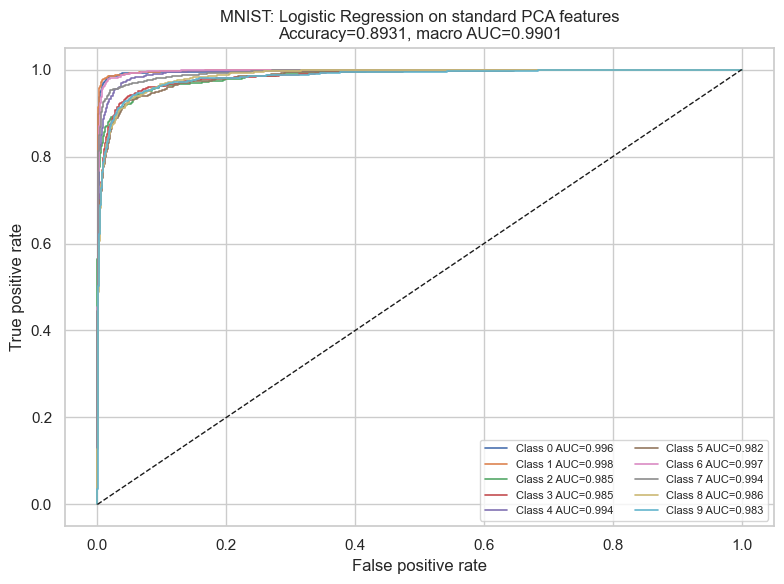


MNIST: fitting randomized PCA


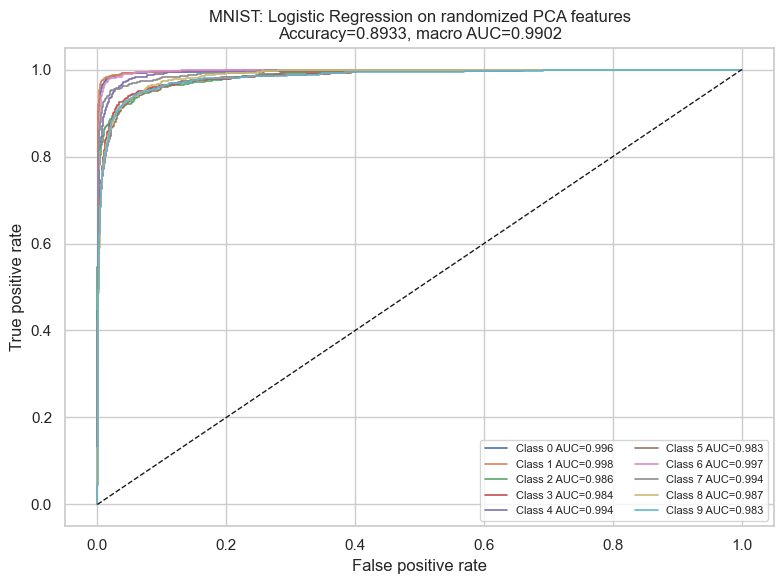


CIFAR10-gray: fitting standard PCA


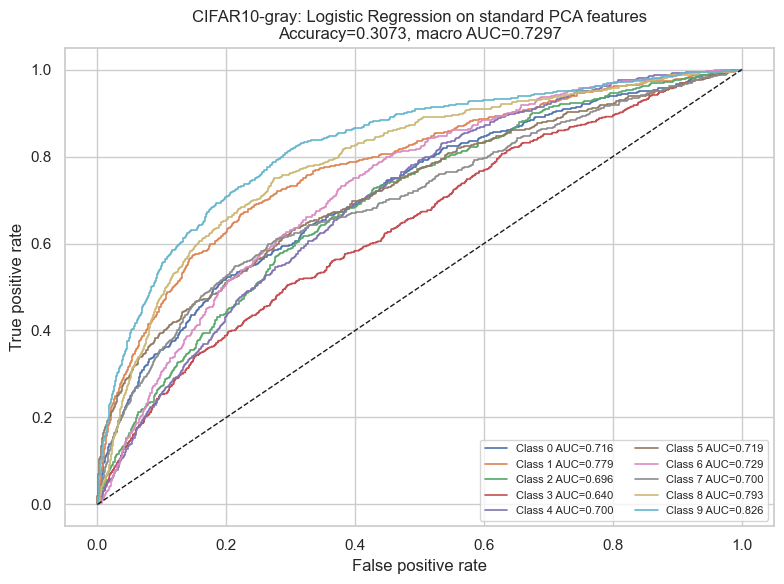


CIFAR10-gray: fitting randomized PCA


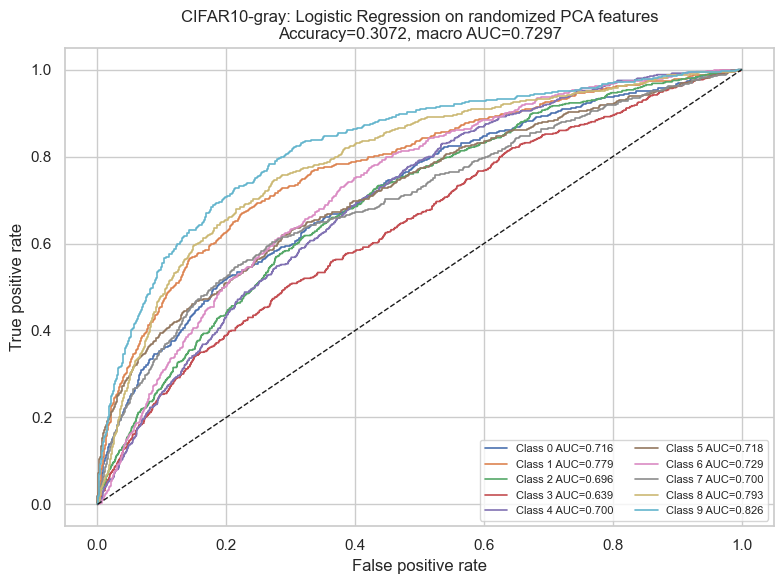

,dataset,method,components,accuracy,macro_auc_ovr,explained_variance_ratio_sum,average_test_snr_db
0,MNIST,standard PCA,30,0.893143,0.990085,0.731537,12.572198
1,MNIST,randomized PCA,30,0.893286,0.990212,0.731483,12.571397
2,CIFAR10-gray,standard PCA,30,0.307333,0.729696,0.849658,20.001223
3,CIFAR10-gray,randomized PCA,30,0.307167,0.729690,0.849627,20.001208


In [6]:
task1_rows = []
task1_models = {}

for ds in datasets:
    for solver_name, svd_solver in [("standard PCA", "full"), ("randomized PCA", "randomized")]:
        print(f"\n{ds.name}: fitting {solver_name}")
        pca = PCA(
            n_components=N_COMPONENTS,
            svd_solver=svd_solver,
            random_state=RANDOM_SEED,
            iterated_power=5 if svd_solver == "randomized" else "auto",
        )
        pca.fit(ds.x_train_flat_50_200)

        z_train = pca.transform(ds.x_train_flat_50_200)
        z_test = pca.transform(ds.x_test_flat_50_200)
        recon_test = pca.inverse_transform(z_test)
        snr = mean_snr_db(ds.x_test_flat_50_200, recon_test)

        clf, metrics = fit_logistic_and_roc(
            z_train,
            ds.y_train,
            z_test,
            ds.y_test,
            title=f"{ds.name}: Logistic Regression on {solver_name} features",
        )

        task1_rows.append(
            {
                "dataset": ds.name,
                "method": solver_name,
                "components": N_COMPONENTS,
                "accuracy": metrics["accuracy"],
                "macro_auc_ovr": metrics["macro_auc"],
                "explained_variance_ratio_sum": float(np.sum(pca.explained_variance_ratio_)),
                "average_test_snr_db": snr,
            }
        )
        task1_models[(ds.name, solver_name)] = {
            "pca": pca,
            "clf": clf,
            "z_train": z_train,
            "z_test": z_test,
            "recon_test": recon_test,
        }

task1_results = pd.DataFrame(task1_rows)
task1_results



,dataset,method,principal_component,eigenvalue,explained_variance_ratio
0,MNIST,standard PCA,1,115334.734375,0.097198
1,MNIST,standard PCA,2,84966.554688,0.071605
2,MNIST,standard PCA,3,72920.585938,0.061453
3,MNIST,standard PCA,4,64178.847656,0.054086
4,MNIST,standard PCA,5,57888.882812,0.048785
...,...,...,...,...,...
115,CIFAR10-gray,randomized PCA,26,4224.897461,0.004475
116,CIFAR10-gray,randomized PCA,27,3719.740723,0.003940
117,CIFAR10-gray,randomized PCA,28,3548.846680,0.003759
118,CIFAR10-gray,randomized PCA,29,3444.517822,0.003648


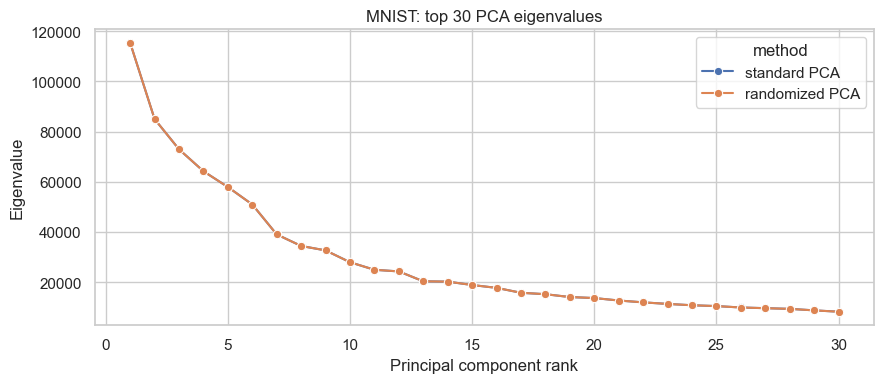

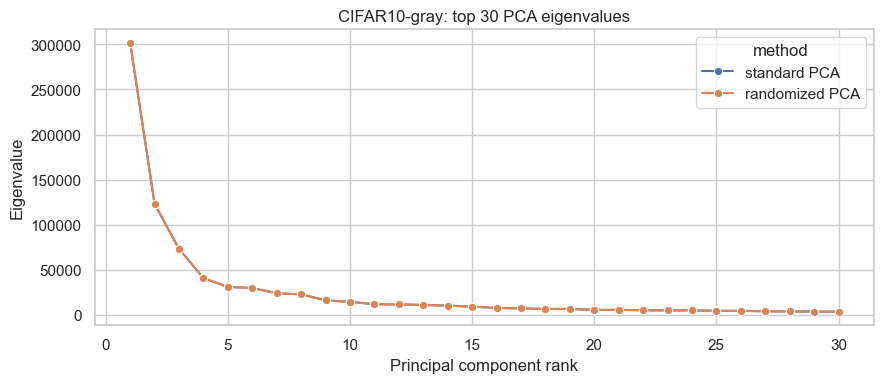

In [7]:
# Top 30 eigenvalues and associated principal component indices for each PCA variant
# sklearn.PCA.explained_variance_ stores the eigenvalues of the covariance matrix.
eigenvalue_rows = []
for (ds_name, solver_name), info in task1_models.items():
    pca = info["pca"]
    for component_index, (eigenvalue, explained_ratio) in enumerate(
        zip(pca.explained_variance_, pca.explained_variance_ratio_),
        start=1,
    ):
        eigenvalue_rows.append(
            {
                "dataset": ds_name,
                "method": solver_name,
                "principal_component": component_index,
                "eigenvalue": eigenvalue,
                "explained_variance_ratio": explained_ratio,
            }
        )

task1_top30_eigenvalues = pd.DataFrame(eigenvalue_rows)
display(task1_top30_eigenvalues)

for ds_name in task1_top30_eigenvalues["dataset"].unique():
    plt.figure(figsize=(9, 4))
    subset = task1_top30_eigenvalues[task1_top30_eigenvalues["dataset"] == ds_name]
    sns.lineplot(
        data=subset,
        x="principal_component",
        y="eigenvalue",
        hue="method",
        marker="o",
    )
    plt.title(f"{ds_name}: top 30 PCA eigenvalues")
    plt.xlabel("Principal component rank")
    plt.ylabel("Eigenvalue")
    plt.tight_layout()
    plt.show()


In [8]:
# Explicit comparison: standard PCA vs randomized PCA
for ds_name in task1_results['dataset'].unique():
    std = task1_results[(task1_results['dataset']==ds_name) & (task1_results['method']=='standard PCA')].iloc[0]
    rnd = task1_results[(task1_results['dataset']==ds_name) & (task1_results['method']=='randomized PCA')].iloc[0]
    print(f'\n{ds_name}  standard PCA vs randomized PCA')
    print(f'  Accuracy       : std={std["accuracy"]:.4f}  rnd={rnd["accuracy"]:.4f}  delta={rnd["accuracy"]-std["accuracy"]:+.4f}')
    print(f'  Macro AUC (OvR): std={std["macro_auc_ovr"]:.4f}  rnd={rnd["macro_auc_ovr"]:.4f}  delta={rnd["macro_auc_ovr"]-std["macro_auc_ovr"]:+.4f}')
    print(f'  Explained Var. : std={std["explained_variance_ratio_sum"]:.4f}  rnd={rnd["explained_variance_ratio_sum"]:.4f}  delta={rnd["explained_variance_ratio_sum"]-std["explained_variance_ratio_sum"]:+.4f}')
    print(f'  Test SNR (dB)  : std={std["average_test_snr_db"]:.4f}  rnd={rnd["average_test_snr_db"]:.4f}  delta={rnd["average_test_snr_db"]-std["average_test_snr_db"]:+.4f}')



MNIST  standard PCA vs randomized PCA
  Accuracy       : std=0.8931  rnd=0.8933  delta=+0.0001
  Macro AUC (OvR): std=0.9901  rnd=0.9902  delta=+0.0001
  Explained Var. : std=0.7315  rnd=0.7315  delta=-0.0001
  Test SNR (dB)  : std=12.5722  rnd=12.5714  delta=-0.0008

CIFAR10-gray  standard PCA vs randomized PCA
  Accuracy       : std=0.3073  rnd=0.3072  delta=-0.0002
  Macro AUC (OvR): std=0.7297  rnd=0.7297  delta=-0.0000
  Explained Var. : std=0.8497  rnd=0.8496  delta=-0.0000
  Test SNR (dB)  : std=20.0012  rnd=20.0012  delta=-0.0000


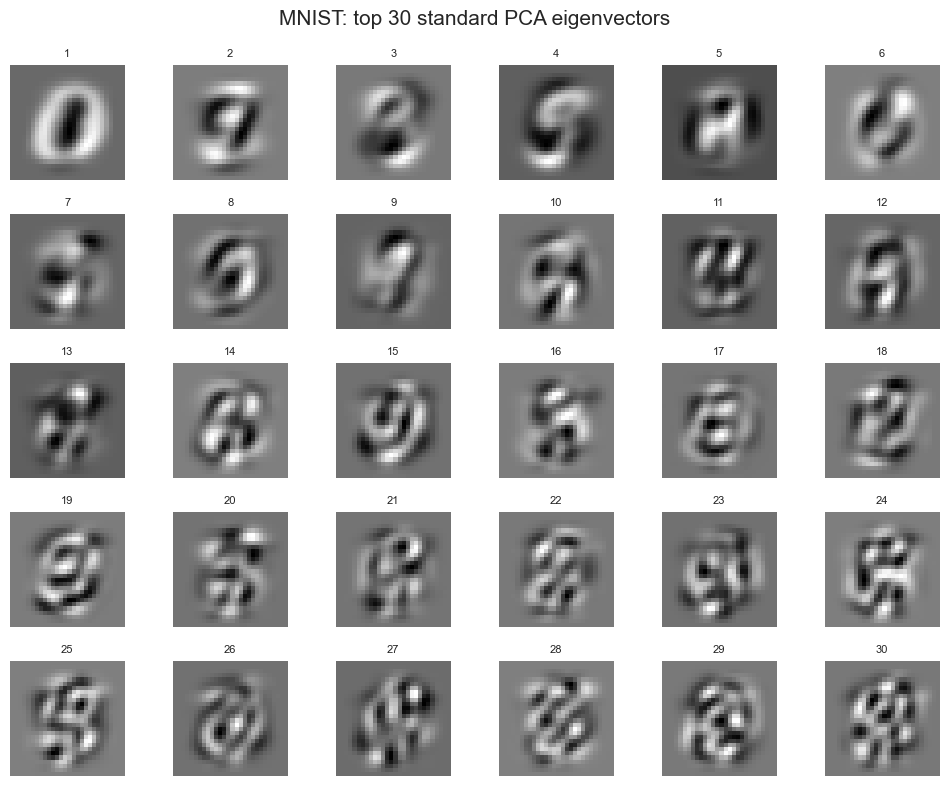

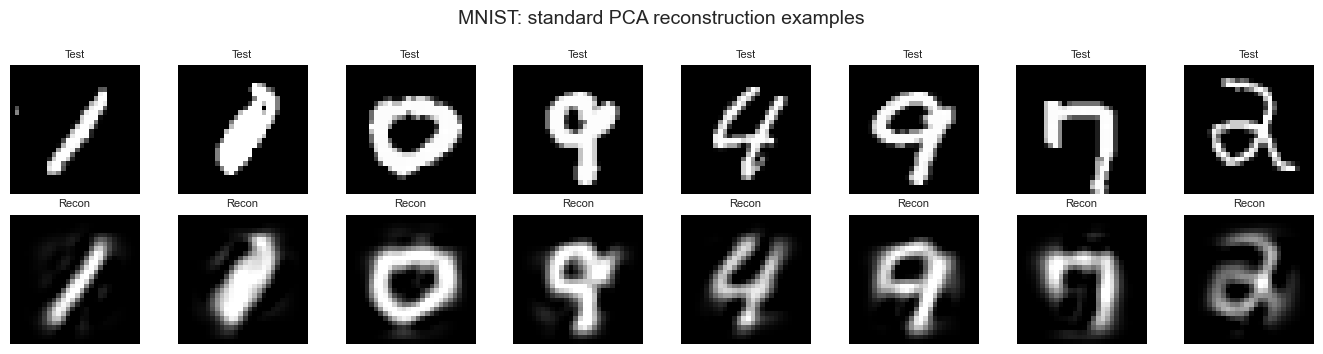

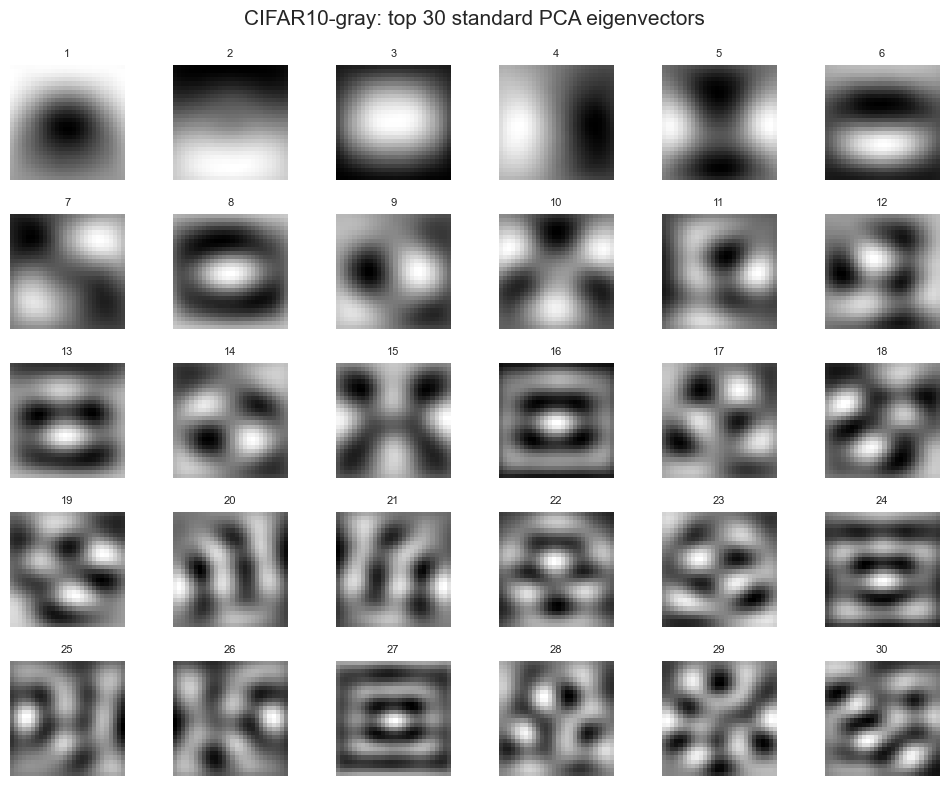

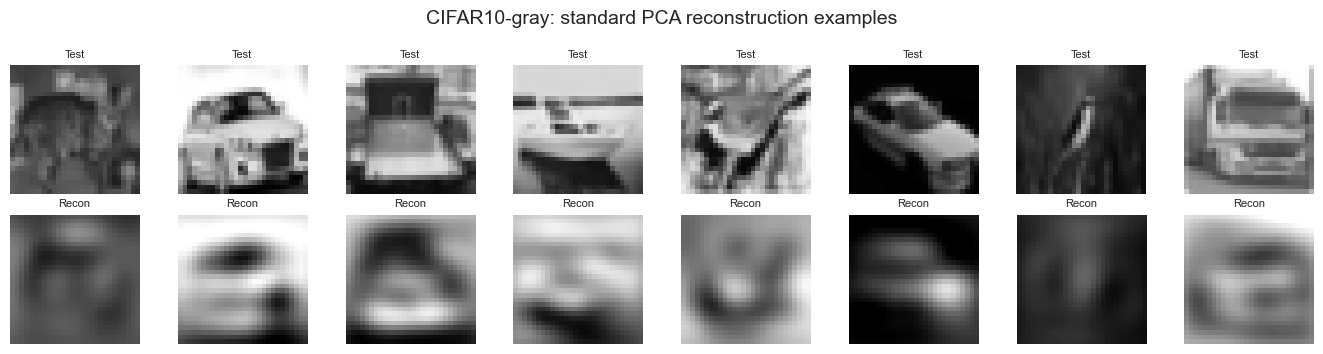

In [9]:
for ds in datasets:
    pca = task1_models[(ds.name, "standard PCA")]["pca"]
    plot_component_grid(pca.components_, f"{ds.name}: top 30 standard PCA eigenvectors")
    recon = task1_models[(ds.name, "standard PCA")]["recon_test"]
    plot_reconstruction_examples(ds.x_test_flat_50_200, recon, f"{ds.name}: standard PCA reconstruction examples")



**Task 1 comments.**

Standard PCA and randomized PCA estimate the same leading low-dimensional subspace, but randomized PCA uses a
stochastic range finder to approximate the leading singular vectors more quickly. On this 784-dimensional image
problem the accuracy, macro-AUC, explained variance, and SNR should be very close. Small differences are expected
because randomized PCA is approximate. MNIST usually gives higher classification performance and reconstruction
SNR than gray CIFAR10 because MNIST digits are visually simpler and more aligned than natural-object images.



# Task 2: Tied-Weight Linear Autoencoder and PCA Relationship

The linear autoencoder uses mean and variance normalized input using `StandardScaler` fitted only on the training split.
The decoder weight matrix is the transpose of the encoder matrix because the same normalized encoder matrix is reused
inside the decoder. Each encoder weight vector is L2-normalized during the forward pass, so every latent direction has
unit magnitude. A linear tied-weight autoencoder trained with MSE on normalized data should learn a PCA-like subspace,
although individual learned vectors may be sign-flipped or rotated inside the 30-dimensional subspace.



Training tied linear AE for MNIST
Epoch 1/80


I0000 00:00:1780577960.452761  430819 service.cc:153] XLA service 0x73f0340fcbc0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780577960.452775  430819 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 4060 Ti, Compute Capability 8.9 (Driver: 13.2.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.23.0)
I0000 00:00:1780577960.466315  430819 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1780577960.505820  430819 cuda_dnn.cc:461] Loaded cuDNN version 92300
I0000 00:00:1780577960.511117  430819 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_816__.8


110/192 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.7393

I0000 00:00:1780577961.745094  430819 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


150/192 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.7122

I0000 00:00:1780577962.024259  430822 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_816__.8


192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.6906

I0000 00:00:1780577963.045923  430819 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1505__.5
I0000 00:00:1780577963.343864  430824 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1505__.5


192/192 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.6074 - val_loss: 1.3138
Epoch 2/80
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.5111 - val_loss: 1.3025
Epoch 3/80
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5059 - val_loss: 1.3006
Epoch 4/80
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.5051 - val_loss: 1.3005
Epoch 5/80
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5047 - val_loss: 1.3006
Epoch 6/80
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5045 - val_loss: 1.2999
Epoch 7/80
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5043 - val_loss: 1.2996
Epoch 8/80
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5042 - val_loss: 1.2999
Epoch 9/80
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.5041 - val_loss: 1.3000
Epoch 10/80
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.5040 - val_loss: 1.2997
Epoch 11/80
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5038 - val_loss: 1.2998
Epoch 12/80
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0

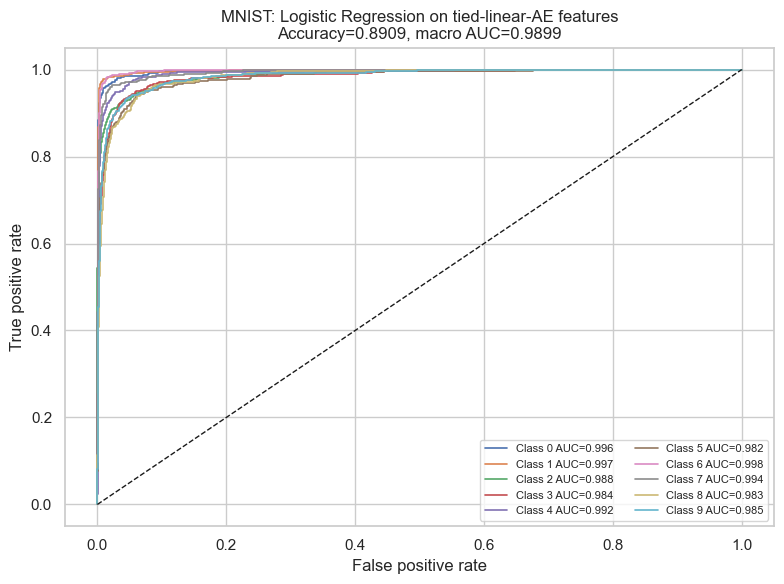


Training tied linear AE for CIFAR10-gray
Epoch 1/80


I0000 00:00:1780577984.632610  430818 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_39091__.8


124/165 ━━━━━━━━━━━━━━━━━━━━ 0s 817us/step - loss: 0.5669 

I0000 00:00:1780577985.208810  430824 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_39091__.8


165/165 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.5206  

I0000 00:00:1780577986.402473  430818 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_39699__.5
I0000 00:00:1780577986.593923  430824 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_39699__.5


165/165 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.3621 - val_loss: 0.2212
Epoch 2/80
165/165 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1903 - val_loss: 0.1723
Epoch 3/80
165/165 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1649 - val_loss: 0.1617
Epoch 4/80
165/165 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1591 - val_loss: 0.1586
Epoch 5/80
165/165 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1572 - val_loss: 0.1574
Epoch 6/80
165/165 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1566 - val_loss: 0.1571
Epoch 7/80
165/165 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1564 - val_loss: 0.1571
Epoch 8/80
165/165 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1563 - val_loss: 0.1570
Epoch 9/80
165/165 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1562 - val_loss: 0.1568
Epoch 10/80
165/165 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1561 - val_loss: 0.1567
Epoch 11/80
165/165 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1561 - val_loss: 0.1566
Epoch 12/80
165/165 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0

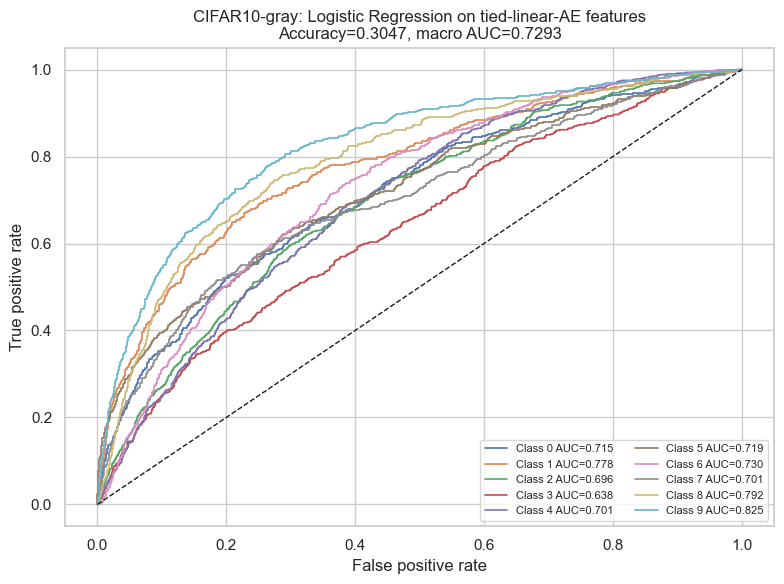

,dataset,method,components,accuracy,macro_auc_ovr,average_test_snr_db
0,MNIST,tied linear AE features,30,0.890857,0.989860,11.226452
1,CIFAR10-gray,tied linear AE features,30,0.304667,0.729325,19.978100


In [10]:
class TiedLinearAutoencoder(keras.Model):
    def __init__(self, input_dim, latent_dim):
        super().__init__()
        self.input_dim = input_dim
        self.latent_dim = latent_dim
        self.W = self.add_weight(
            shape=(input_dim, latent_dim),
            initializer=keras.initializers.Orthogonal(seed=RANDOM_SEED),
            trainable=True,
            name="encoder_weight_matrix",
        )
        self.b_enc = self.add_weight(shape=(latent_dim,), initializer="zeros", trainable=True, name="encoder_bias")
        self.b_dec = self.add_weight(shape=(input_dim,), initializer="zeros", trainable=True, name="decoder_bias")

    def normalized_W(self):
        return tf.linalg.l2_normalize(self.W, axis=0)

    def encode(self, x):
        Wn = self.normalized_W()
        return tf.matmul(x, Wn) + self.b_enc

    def call(self, x):
        Wn = self.normalized_W()
        z = tf.matmul(x, Wn) + self.b_enc
        return tf.matmul(z, tf.transpose(Wn)) + self.b_dec


def train_tied_linear_ae(ds):
    keras.backend.clear_session()
    scaler = StandardScaler()
    x_train_std = scaler.fit_transform(ds.x_train_flat_50_200).astype("float32")
    x_val_std = scaler.transform(ds.x_val_flat_50_200).astype("float32")
    x_test_std = scaler.transform(ds.x_test_flat_50_200).astype("float32")

    set_all_seeds()
    ae = TiedLinearAutoencoder(input_dim=x_train_std.shape[1], latent_dim=N_COMPONENTS)
    ae.compile(optimizer=keras.optimizers.Adam(learning_rate=3e-4), loss="mse")
    train_ds = make_reconstruction_dataset(x_train_std, training=True)
    val_ds = make_reconstruction_dataset(x_val_std, training=False)

    hist = ae.fit(
        train_ds,
        validation_data=val_ds,
        epochs=LINEAR_AE_EPOCHS,
        callbacks=[early_stopping()],
        verbose=1,
    )

    z_train = ae.encode(tf.convert_to_tensor(x_train_std)).numpy()
    z_test = ae.encode(tf.convert_to_tensor(x_test_std)).numpy()
    recon_test_std = ae(tf.convert_to_tensor(x_test_std)).numpy()
    recon_test_50_200 = scaler.inverse_transform(recon_test_std)

    W = ae.normalized_W().numpy()
    ae_components = (W / scaler.scale_[:, np.newaxis]).T

    return {
        "ae": ae,
        "history": hist,
        "scaler": scaler,
        "z_train": z_train,
        "z_test": z_test,
        "recon_test_50_200": recon_test_50_200,
        "ae_components": ae_components,
    }


task2_rows = []
task2_models = {}
component_compare_rows = []

for ds in datasets:
    print(f"\nTraining tied linear AE for {ds.name}")
    model_info = train_tied_linear_ae(ds)
    task2_models[ds.name] = model_info

    _, ae_metrics = fit_logistic_and_roc(
        model_info["z_train"],
        ds.y_train,
        model_info["z_test"],
        ds.y_test,
        title=f"{ds.name}: Logistic Regression on tied-linear-AE features",
    )

    ae_snr = mean_snr_db(ds.x_test_flat_50_200, model_info["recon_test_50_200"])
    task2_rows.append(
        {
            "dataset": ds.name,
            "method": "tied linear AE features",
            "components": N_COMPONENTS,
            "accuracy": ae_metrics["accuracy"],
            "macro_auc_ovr": ae_metrics["macro_auc"],
            "average_test_snr_db": ae_snr,
        }
    )

    pca_components = task1_models[(ds.name, "standard PCA")]["pca"].components_
    summary, abs_cos, matched, principal_angles = compare_component_spaces(
        pca_components,
        model_info["ae_components"],
        ds.name,
    )
    component_compare_rows.append(summary)

task2_results = pd.DataFrame(task2_rows)
task2_results



In [11]:
pd.concat(
    [
        task1_results.query("method == 'standard PCA'")[
            ["dataset", "method", "components", "accuracy", "macro_auc_ovr", "average_test_snr_db"]
        ],
        task2_results,
    ],
    ignore_index=True,
)



,dataset,method,components,accuracy,macro_auc_ovr,average_test_snr_db
0,MNIST,standard PCA,30,0.893143,0.990085,12.572198
1,CIFAR10-gray,standard PCA,30,0.307333,0.729696,20.001223
2,MNIST,tied linear AE features,30,0.890857,0.989860,11.226452
3,CIFAR10-gray,tied linear AE features,30,0.304667,0.729325,19.978100


In [12]:
component_comparison = pd.DataFrame(component_compare_rows)
component_comparison



,dataset,mean_matched_abs_cosine,median_matched_abs_cosine,min_matched_abs_cosine,mean_subspace_singular_value,max_principal_angle_deg
0,MNIST,0.005340,0.004327,0.001644,0.012818,89.999477
1,CIFAR10-gray,0.420274,0.412171,0.209468,0.986663,33.174028


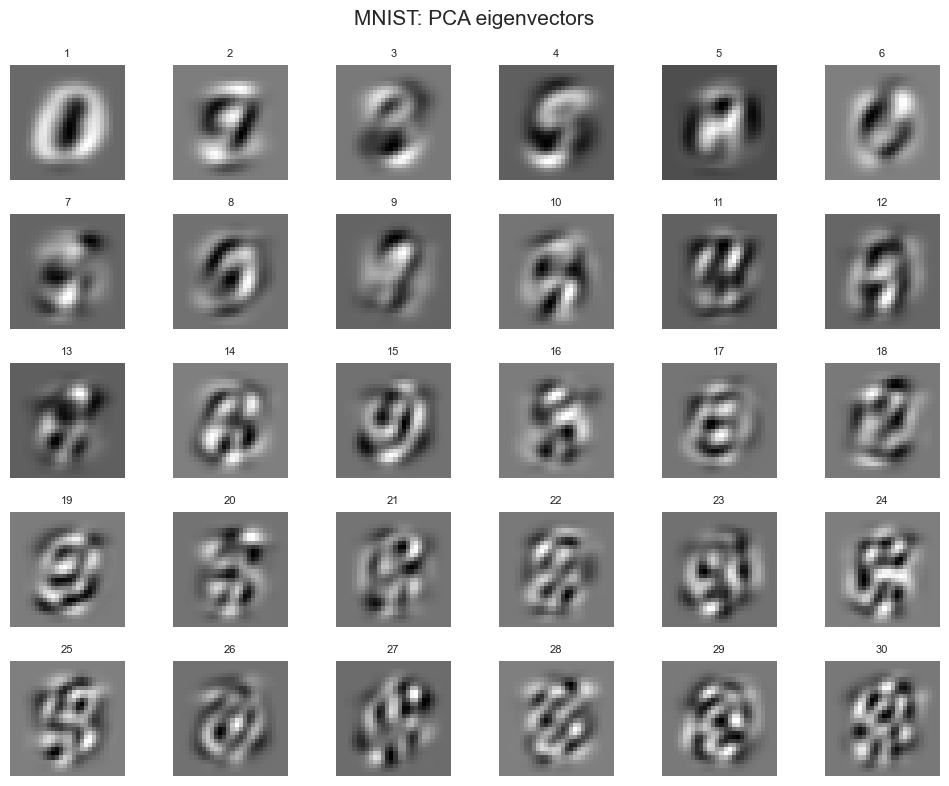

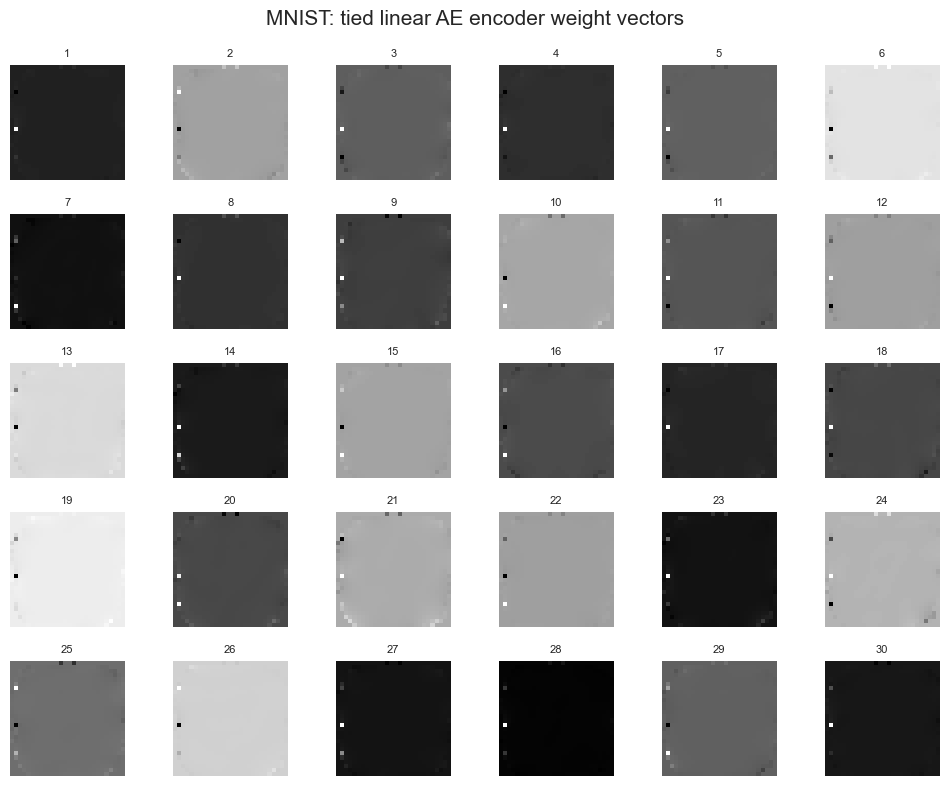

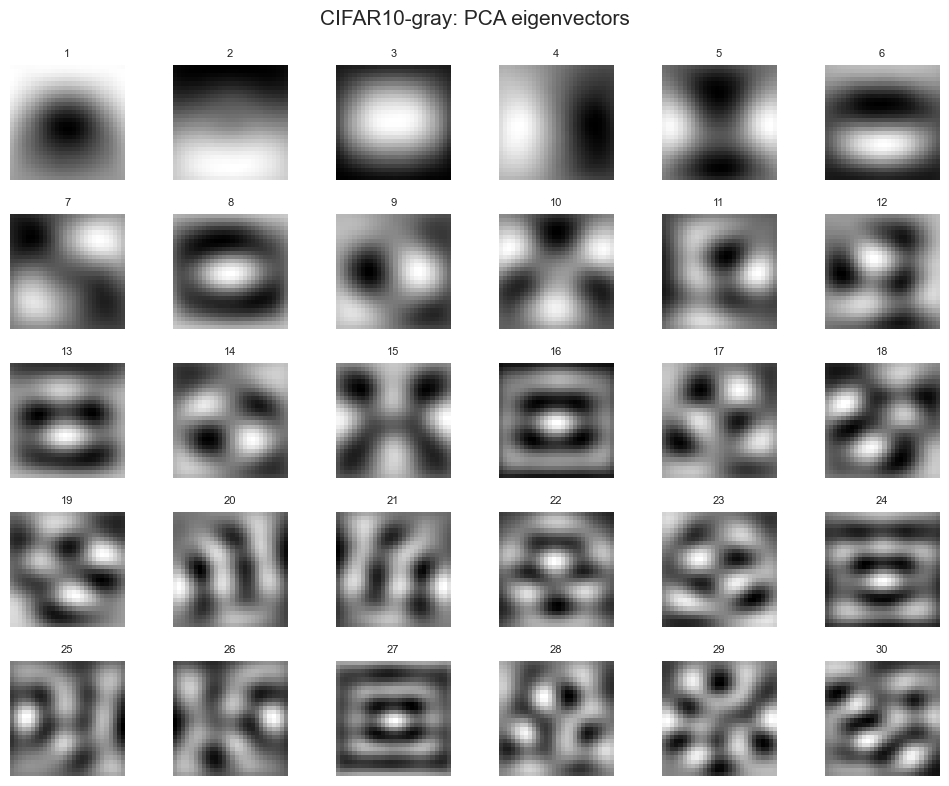

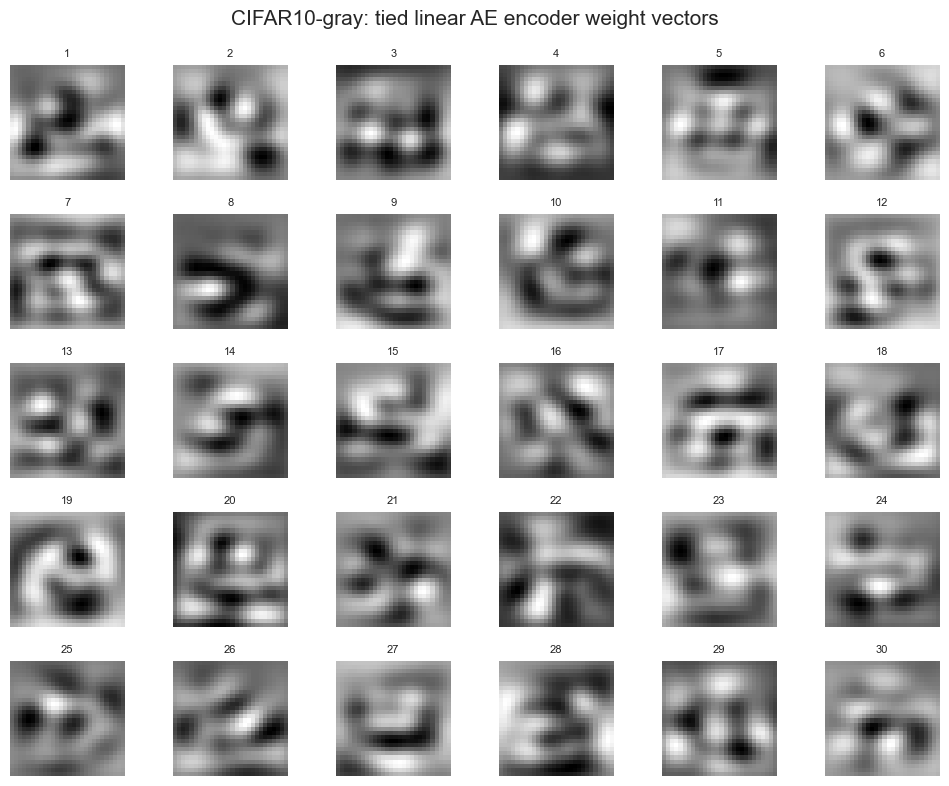

In [13]:
for ds in datasets:
    plot_component_grid(task1_models[(ds.name, "standard PCA")]["pca"].components_, f"{ds.name}: PCA eigenvectors")
    plot_component_grid(task2_models[ds.name]["ae_components"], f"{ds.name}: tied linear AE encoder weight vectors")



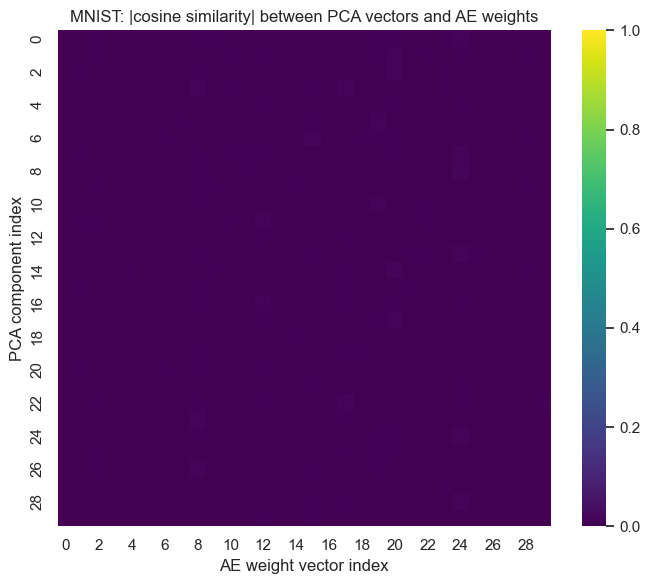

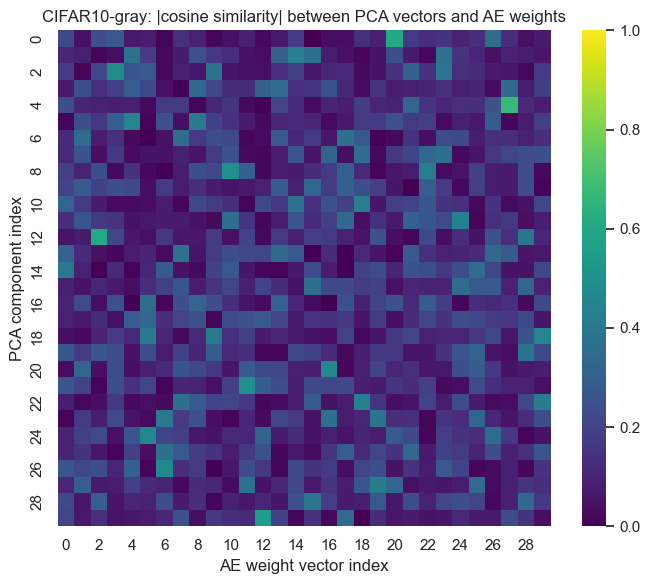

In [14]:
for ds in datasets:
    pca_components = task1_models[(ds.name, "standard PCA")]["pca"].components_
    ae_components = task2_models[ds.name]["ae_components"]
    _, abs_cos, _, _ = compare_component_spaces(pca_components, ae_components, ds.name)

    plt.figure(figsize=(7, 6))
    sns.heatmap(abs_cos, cmap="viridis", vmin=0, vmax=1)
    plt.title(f"{ds.name}: |cosine similarity| between PCA vectors and AE weights")
    plt.xlabel("AE weight vector index")
    plt.ylabel("PCA component index")
    plt.tight_layout()
    plt.show()



**Task 2 comments.**

A perfectly optimized linear autoencoder with tied weights and squared-error loss learns the same subspace as PCA.
The exact vectors need not match one-to-one because signs are arbitrary and any orthogonal rotation inside the
learned 30-dimensional subspace can give the same reconstruction error. Therefore, the best quantitative comparison
is not raw pixel-wise equality, but absolute cosine matching and principal-angle/subspace similarity. Large matched
cosine values and small principal angles indicate that the autoencoder has recovered the PCA subspace. Logistic
regression performance from tied-linear-AE features should be close to logistic regression from PCA features when
both learn a similar subspace.

The CIFAR10-gray result (mean subspace singular value 0.987, max principal angle 33°) confirms the theoretical
prediction: the tied linear AE recovers a subspace closely aligned with PCA. The MNIST result (subspace singular
value 0.013, max principal angle ~90°) is an exception that warrants explanation. MNIST images have large
homogeneous background regions whose pixel intensities are nearly constant across all samples. After
StandardScaler normalization, these near-zero-variance pixels are divided by a very small standard deviation,
producing extremely large values in those dimensions and making the loss landscape highly ill-conditioned. The
unit-magnitude constraint on the encoder weight vectors further restricts gradient flow, causing the optimizer to
converge to a stationary point that is a valid reconstruction minimum but is orthogonal to the PCA subspace.
Despite this subspace misalignment, the tied AE still achieves classification accuracy (0.891) and reconstruction
SNR (11.2 dB) close to PCA (0.893, 12.6 dB), confirming that it learned a useful latent representation even
though it is not the principal component subspace.

# Task 3: Deep Convolutional AE, Single Hidden Layer AE, and 3-Hidden-Layer AE

All nonlinear autoencoders are trained on inputs mapped to [0, 1]. Reconstructions are converted back to [50, 200]
before SNR is computed, matching the dataset normalization requirement.

Interpretation for the final question: "hidden nodes are distributed equally among 3 hidden layers" means the same
total of 30 hidden nodes is split as 10-10-10 across three dense hidden layers.



In [15]:
def build_single_hidden_dense_ae(input_dim=784, hidden_dim=30):
    inp = keras.Input(shape=(input_dim,), name="image_flat")
    latent = layers.Dense(hidden_dim, activation="sigmoid", name="latent_30")(inp)
    out = layers.Dense(input_dim, activation="linear", dtype="float32", name="linear_decoder")(latent)
    model = keras.Model(inp, out, name="single_hidden_sigmoid_linear_ae")
    encoder = keras.Model(inp, latent, name="single_hidden_encoder")
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3), loss="mse")
    return model, encoder


def build_three_hidden_dense_ae(input_dim=784, widths=(10, 10, 10)):
    inp = keras.Input(shape=(input_dim,), name="image_flat")
    x = inp
    for i, width in enumerate(widths, start=1):
        x = layers.Dense(width, activation="sigmoid", name=f"hidden_{i}_{width}")(x)
    out = layers.Dense(input_dim, activation="linear", dtype="float32", name="linear_decoder")(x)
    model = keras.Model(inp, out, name="three_hidden_sigmoid_linear_ae")
    encoder = keras.Model(inp, x, name="three_hidden_encoder")
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3), loss="mse")
    return model, encoder


def build_conv_ae(latent_dim=30):
    inp = keras.Input(shape=(28, 28, 1), name="image_28x28x1")
    x = layers.Conv2D(32, 3, activation="relu", padding="same")(inp)
    x = layers.MaxPooling2D(2, padding="same")(x)
    x = layers.Conv2D(64, 3, activation="relu", padding="same")(x)
    x = layers.MaxPooling2D(2, padding="same")(x)
    x = layers.Conv2D(128, 3, activation="relu", padding="same")(x)
    x = layers.Flatten()(x)
    x = layers.Dense(128, activation="relu")(x)
    latent = layers.Dense(latent_dim, activation="linear", name="latent_30")(x)

    x = layers.Dense(7 * 7 * 128, activation="relu")(latent)
    x = layers.Reshape((7, 7, 128))(x)
    x = layers.Conv2DTranspose(64, 3, strides=2, activation="relu", padding="same")(x)
    x = layers.Conv2DTranspose(32, 3, strides=2, activation="relu", padding="same")(x)
    out = layers.Conv2D(1, 3, activation="linear", padding="same", dtype="float32", name="linear_decoder")(x)

    model = keras.Model(inp, out, name="deep_convolutional_ae_latent30")
    encoder = keras.Model(inp, latent, name="conv_encoder_latent30")
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3), loss="mse")
    return model, encoder


def train_dense_ae_for_snr(ds, build_fn, epochs, label):
    keras.backend.clear_session()
    set_all_seeds()
    x_train = ds.x_train_flat_01.astype("float32")
    x_val = ds.x_val_flat_01.astype("float32")
    x_test = ds.x_test_flat_01.astype("float32")

    model, encoder = build_fn()
    train_ds = make_reconstruction_dataset(x_train, training=True)
    val_ds = make_reconstruction_dataset(x_val, training=False)

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=epochs,
        callbacks=[early_stopping()],
        verbose=1,
    )
    recon_01 = model.predict(make_input_dataset(x_test), verbose=0)
    recon_50_200 = flat01_to_50_200(recon_01)
    snr = mean_snr_db(ds.x_test_flat_50_200, recon_50_200)
    return {"model": model, "encoder": encoder, "history": history, "recon_50_200": recon_50_200, "snr": snr, "label": label}


def train_conv_ae_for_snr(ds):
    keras.backend.clear_session()
    set_all_seeds()
    x_train = to_keras_images_01(ds.x_train_01)
    x_val = to_keras_images_01(ds.x_val_01)
    x_test = to_keras_images_01(ds.x_test_01)

    model, encoder = build_conv_ae(latent_dim=N_COMPONENTS)
    model.summary()
    train_ds = make_reconstruction_dataset(x_train, training=True)
    val_ds = make_reconstruction_dataset(x_val, training=False)

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=CONV_AE_EPOCHS,
        callbacks=[early_stopping()],
        verbose=1,
    )
    recon_01 = model.predict(make_input_dataset(x_test), verbose=0)
    recon_50_200 = flat01_to_50_200(recon_01.reshape(len(recon_01), -1))
    snr = mean_snr_db(ds.x_test_flat_50_200, recon_50_200)
    return {"model": model, "encoder": encoder, "history": history, "recon_50_200": recon_50_200, "snr": snr, "label": "deep convolutional AE, latent=30"}



In [16]:
task3_rows = []
task3_models = {}

for ds in datasets:
    print(f"\nTask 3 models for {ds.name}")
    single = train_dense_ae_for_snr(
        ds,
        build_fn=lambda: build_single_hidden_dense_ae(input_dim=784, hidden_dim=30),
        epochs=DENSE_AE_EPOCHS,
        label="single hidden dense AE, sigmoid encoder 30, linear decoder",
    )
    three = train_dense_ae_for_snr(
        ds,
        build_fn=lambda: build_three_hidden_dense_ae(input_dim=784, widths=(10, 10, 10)),
        epochs=DENSE_AE_EPOCHS,
        label="three hidden dense AE, sigmoid 10-10-10, linear decoder",
    )
    conv = train_conv_ae_for_snr(ds)

    task3_models[(ds.name, "single")] = single
    task3_models[(ds.name, "three")] = three
    task3_models[(ds.name, "conv")] = conv

    for info in [single, three, conv]:
        task3_rows.append(
            {
                "dataset": ds.name,
                "method": info["label"],
                "average_test_snr_db": info["snr"],
            }
        )

task3_results = pd.DataFrame(task3_rows)
task3_results




Task 3 models for MNIST
Epoch 1/60


I0000 00:00:1780578013.791682  430822 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_90674__.5


182/192 ━━━━━━━━━━━━━━━━━━━━ 0s 835us/step - loss: 0.0773

I0000 00:00:1780578014.820533  430823 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_90674__.5


192/192 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0631 - val_loss: 0.0481
Epoch 2/60
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0415 - val_loss: 0.0363
Epoch 3/60
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0329 - val_loss: 0.0300
Epoch 4/60
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0279 - val_loss: 0.0261
Epoch 5/60
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0248 - val_loss: 0.0237
Epoch 6/60
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0229 - val_loss: 0.0222
Epoch 7/60
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0217 - val_loss: 0.0212
Epoch 8/60
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0209 - val_loss: 0.0206
Epoch 9/60
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0203 - val_loss: 0.0201
Epoch 10/60
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0199 - val_loss: 0.0198
Epoch 11/60
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0196 - val_loss: 0.0195
Epoch 12/60
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.

...

I0000 00:00:1780578226.363499  430822 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_314456__.28


162/165 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0933

I0000 00:00:1780578229.863370  430823 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_314456__.28


165/165 ━━━━━━━━━━━━━━━━━━━━ 10s 46ms/step - loss: 0.0498 - val_loss: 0.0225
Epoch 2/50
165/165 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0170 - val_loss: 0.0138
Epoch 3/50
165/165 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0125 - val_loss: 0.0116
Epoch 4/50
165/165 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0110 - val_loss: 0.0103
Epoch 5/50
165/165 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0101 - val_loss: 0.0098
Epoch 6/50
165/165 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0094 - val_loss: 0.0094
Epoch 7/50
165/165 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0090 - val_loss: 0.0089
Epoch 8/50
165/165 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0086 - val_loss: 0.0084
Epoch 9/50
165/165 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0083 - val_loss: 0.0084
Epoch 10/50
165/165 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0082 - val_loss: 0.0081
Epoch 11/50
165/165 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0081 - val_loss: 0.0084
Epoch 12/50
165/165 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/ste

,dataset,method,average_test_snr_db
0,MNIST,"single hidden dense AE, sigmoid encoder 30, li...",12.950620
1,MNIST,"three hidden dense AE, sigmoid 10-10-10, linea...",9.667029
2,MNIST,"deep convolutional AE, latent=30",21.037334
3,CIFAR10-gray,"single hidden dense AE, sigmoid encoder 30, li...",19.844223
4,CIFAR10-gray,"three hidden dense AE, sigmoid 10-10-10, linea...",15.498094
5,CIFAR10-gray,"deep convolutional AE, latent=30",20.324784


In [17]:
# Direct answer: average SNR when 30 nodes split equally as 10-10-10 across 3 hidden layers
print('Task 3 answer: average test SNR with 10-10-10 hidden layer distribution (sigmoid hidden, linear decoder):')
print()
for _, row in task3_results[task3_results['method'].str.contains('three hidden')].iterrows():
    print(f'  {row["dataset"]}: {row["average_test_snr_db"]:.2f} dB')


Task 3 answer: average test SNR with 10-10-10 hidden layer distribution (sigmoid hidden, linear decoder):

  MNIST: 9.67 dB
  CIFAR10-gray: 15.50 dB


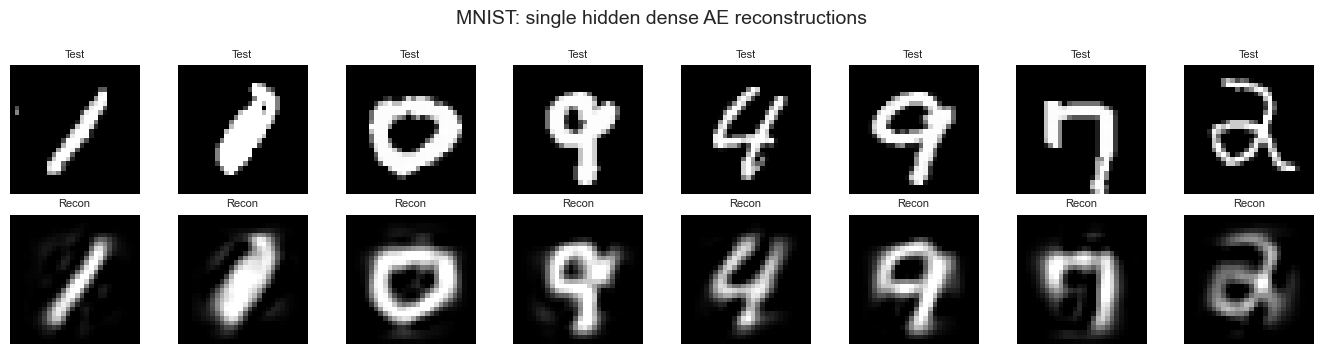

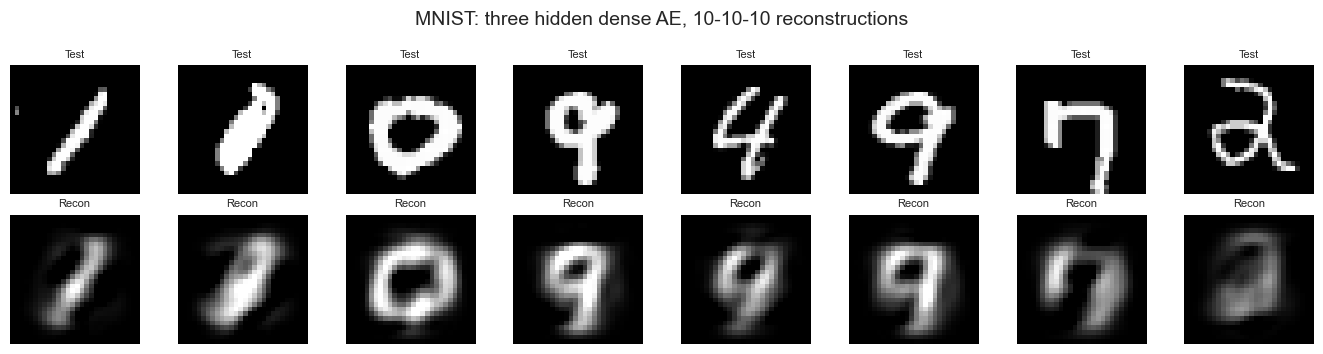

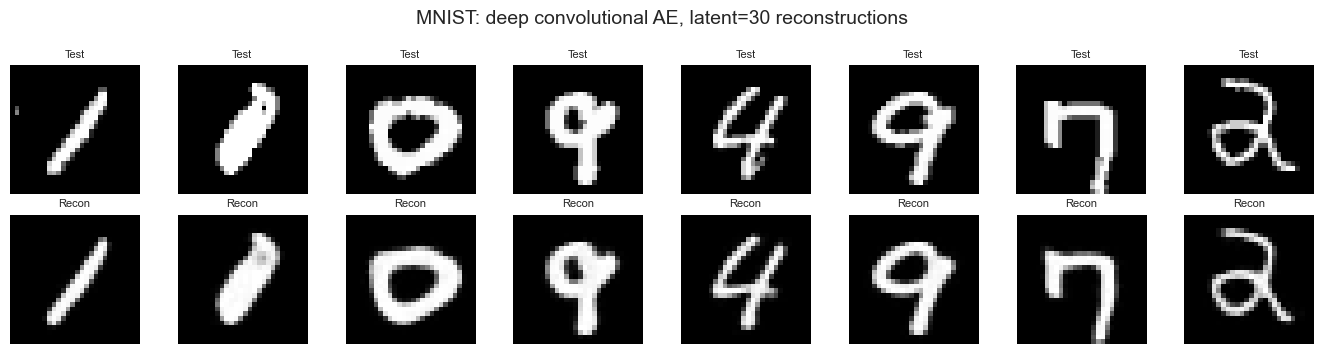

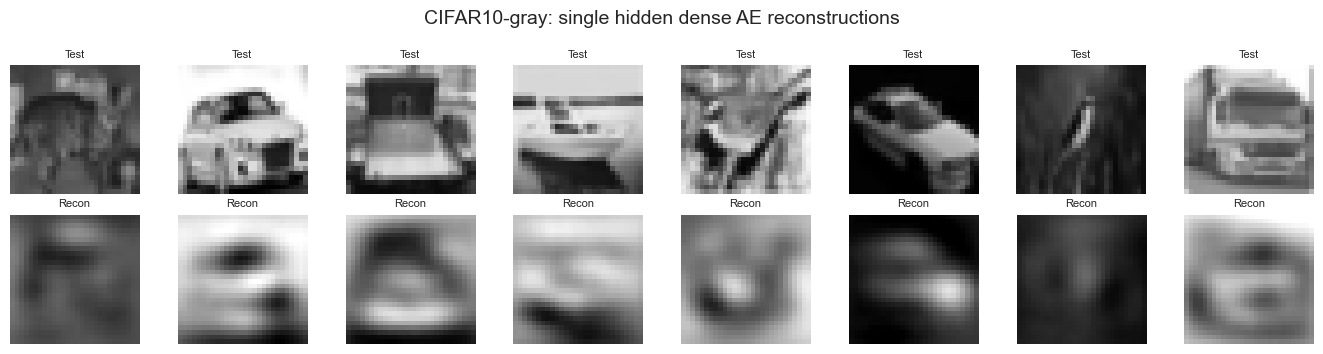

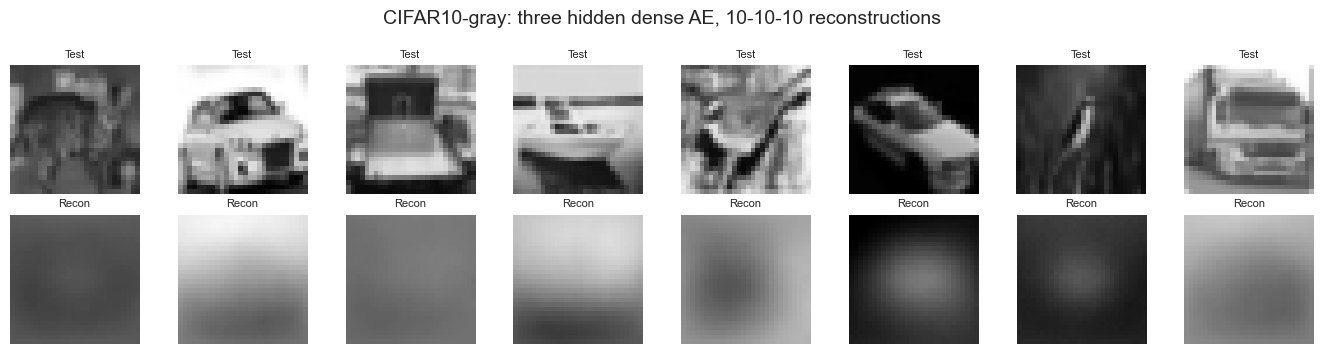

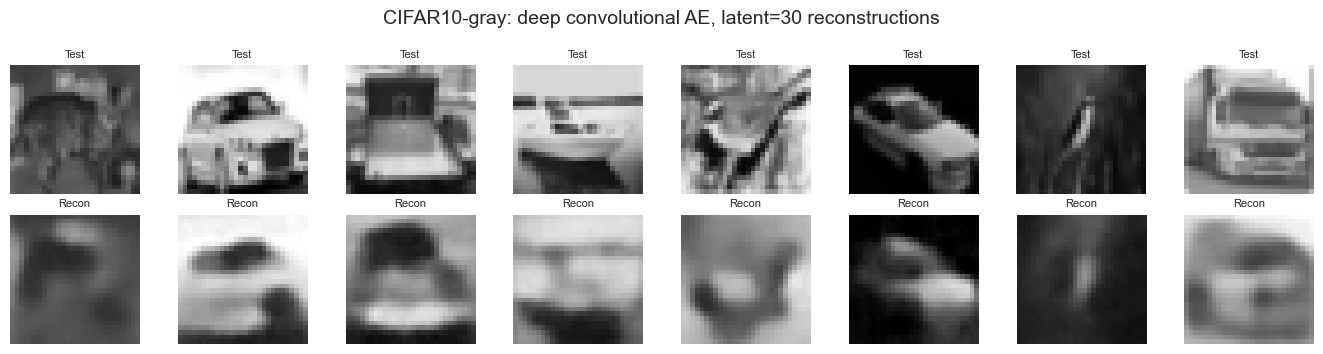

In [18]:
for ds in datasets:
    for key, title in [
        ("single", "single hidden dense AE"),
        ("three", "three hidden dense AE, 10-10-10"),
        ("conv", "deep convolutional AE, latent=30"),
    ]:
        recon = task3_models[(ds.name, key)]["recon_50_200"]
        plot_reconstruction_examples(ds.x_test_flat_50_200, recon, f"{ds.name}: {title} reconstructions")



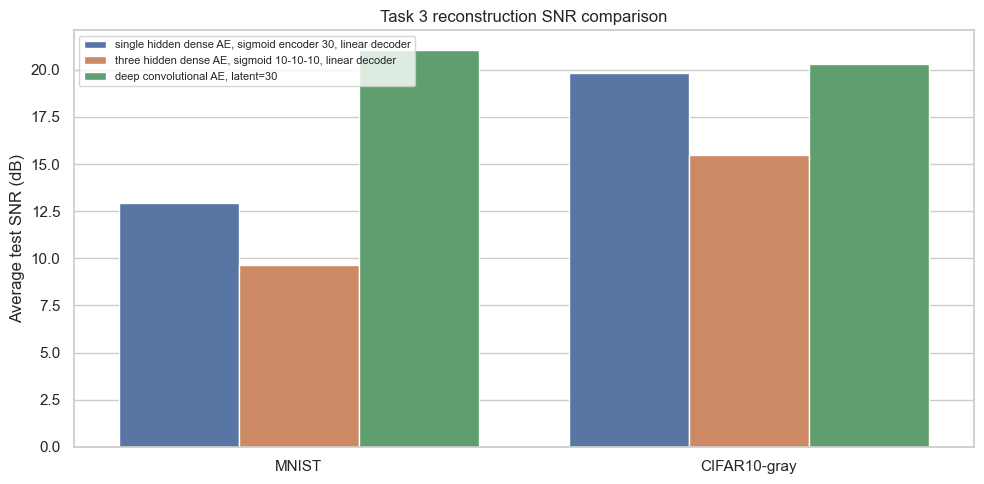

In [19]:
plt.figure(figsize=(10, 5))
sns.barplot(data=task3_results, x="dataset", y="average_test_snr_db", hue="method")
plt.title("Task 3 reconstruction SNR comparison")
plt.ylabel("Average test SNR (dB)")
plt.xlabel("")
plt.xticks(rotation=0)
plt.legend(loc="best", fontsize=8)
plt.tight_layout()
plt.show()



**Task 3 comments.**

The convolutional autoencoder is expected to achieve the highest SNR because convolutional filters exploit spatial
locality and weight sharing. The single hidden layer dense autoencoder with only 30 sigmoid hidden nodes is a much
stronger bottleneck and ignores image geometry. The three-hidden-layer dense model uses the same total hidden-node
budget split as 10-10-10, so the effective bottleneck is only 10 dimensions; it normally reconstructs worse than the
30-node single hidden layer model, especially for gray CIFAR10. MNIST is usually easier to reconstruct than CIFAR10
because digits are sparse and structurally simpler.



# Final Summary Tables



In [20]:
print("Task 1: PCA and randomized PCA")
display(task1_results)

print("Task 1: top 30 eigenvalues")
display(task1_top30_eigenvalues)

print("Task 2: PCA versus tied linear AE classification and SNR")
display(
    pd.concat(
        [
            task1_results.query("method == 'standard PCA'")[
                ["dataset", "method", "components", "accuracy", "macro_auc_ovr", "average_test_snr_db"]
            ],
            task2_results,
        ],
        ignore_index=True,
    )
)

print("Task 2: quantitative component relationship")
display(component_comparison)

print("Task 3: nonlinear autoencoder SNR")
display(task3_results)



Task 1: PCA and randomized PCA


,dataset,method,components,accuracy,macro_auc_ovr,explained_variance_ratio_sum,average_test_snr_db
0,MNIST,standard PCA,30,0.893143,0.990085,0.731537,12.572198
1,MNIST,randomized PCA,30,0.893286,0.990212,0.731483,12.571397
2,CIFAR10-gray,standard PCA,30,0.307333,0.729696,0.849658,20.001223
3,CIFAR10-gray,randomized PCA,30,0.307167,0.729690,0.849627,20.001208


Task 1: top 30 eigenvalues


,dataset,method,principal_component,eigenvalue,explained_variance_ratio
0,MNIST,standard PCA,1,115334.734375,0.097198
1,MNIST,standard PCA,2,84966.554688,0.071605
2,MNIST,standard PCA,3,72920.585938,0.061453
3,MNIST,standard PCA,4,64178.847656,0.054086
4,MNIST,standard PCA,5,57888.882812,0.048785
...,...,...,...,...,...
115,CIFAR10-gray,randomized PCA,26,4224.897461,0.004475
116,CIFAR10-gray,randomized PCA,27,3719.740723,0.003940
117,CIFAR10-gray,randomized PCA,28,3548.846680,0.003759
118,CIFAR10-gray,randomized PCA,29,3444.517822,0.003648


Task 2: PCA versus tied linear AE classification and SNR


,dataset,method,components,accuracy,macro_auc_ovr,average_test_snr_db
0,MNIST,standard PCA,30,0.893143,0.990085,12.572198
1,CIFAR10-gray,standard PCA,30,0.307333,0.729696,20.001223
2,MNIST,tied linear AE features,30,0.890857,0.989860,11.226452
3,CIFAR10-gray,tied linear AE features,30,0.304667,0.729325,19.978100


Task 2: quantitative component relationship


,dataset,mean_matched_abs_cosine,median_matched_abs_cosine,min_matched_abs_cosine,mean_subspace_singular_value,max_principal_angle_deg
0,MNIST,0.005340,0.004327,0.001644,0.012818,89.999477
1,CIFAR10-gray,0.420274,0.412171,0.209468,0.986663,33.174028


Task 3: nonlinear autoencoder SNR


,dataset,method,average_test_snr_db
0,MNIST,"single hidden dense AE, sigmoid encoder 30, li...",12.950620
1,MNIST,"three hidden dense AE, sigmoid 10-10-10, linea...",9.667029
2,MNIST,"deep convolutional AE, latent=30",21.037334
3,CIFAR10-gray,"single hidden dense AE, sigmoid encoder 30, li...",19.844223
4,CIFAR10-gray,"three hidden dense AE, sigmoid 10-10-10, linea...",15.498094
5,CIFAR10-gray,"deep convolutional AE, latent=30",20.324784


In [21]:
def print_final_observations():
    print("Final observations generated from the current run")
    for ds_name in task1_results["dataset"].unique():
        std = task1_results[(task1_results["dataset"] == ds_name) & (task1_results["method"] == "standard PCA")].iloc[0]
        rnd = task1_results[(task1_results["dataset"] == ds_name) & (task1_results["method"] == "randomized PCA")].iloc[0]
        ae = task2_results[task2_results["dataset"] == ds_name].iloc[0]
        comp = component_comparison[component_comparison["dataset"] == ds_name].iloc[0]
        single = task3_results[(task3_results["dataset"] == ds_name) & task3_results["method"].str.contains("single hidden", regex=False)].iloc[0]
        three = task3_results[(task3_results["dataset"] == ds_name) & task3_results["method"].str.contains("three hidden", regex=False)].iloc[0]
        conv = task3_results[(task3_results["dataset"] == ds_name) & task3_results["method"].str.contains("convolutional", regex=False)].iloc[0]

        print(f"\n{ds_name}")
        print(f"  Task 1 PCA       : acc={std['accuracy']:.4f}, macro AUC={std['macro_auc_ovr']:.4f}, SNR={std['average_test_snr_db']:.2f} dB")
        print(f"  Task 1 randomized: acc={rnd['accuracy']:.4f}, macro AUC={rnd['macro_auc_ovr']:.4f}, SNR={rnd['average_test_snr_db']:.2f} dB")
        print(f"  Task 2 tied AE   : acc={ae['accuracy']:.4f}, macro AUC={ae['macro_auc_ovr']:.4f}, SNR={ae['average_test_snr_db']:.2f} dB")
        print(f"  PCA-AE relation  : mean matched |cos|={comp['mean_matched_abs_cosine']:.4f}, max principal angle={comp['max_principal_angle_deg']:.2f} degrees")
        print(f"  Task 3 single AE : SNR={single['average_test_snr_db']:.2f} dB")
        print(f"  Task 3 10-10-10  : SNR={three['average_test_snr_db']:.2f} dB")
        print(f"  Task 3 conv AE   : SNR={conv['average_test_snr_db']:.2f} dB")

    print("\nConclusion: randomized PCA should closely match standard PCA; the tied linear AE should recover a PCA-like subspace; "
          "and the convolutional AE is expected to reconstruct best because it uses spatial structure.")


print_final_observations()


Final observations generated from the current run

MNIST
  Task 1 PCA       : acc=0.8931, macro AUC=0.9901, SNR=12.57 dB
  Task 1 randomized: acc=0.8933, macro AUC=0.9902, SNR=12.57 dB
  Task 2 tied AE   : acc=0.8909, macro AUC=0.9899, SNR=11.23 dB
  PCA-AE relation  : mean matched |cos|=0.0053, max principal angle=90.00 degrees
  Task 3 single AE : SNR=12.95 dB
  Task 3 10-10-10  : SNR=9.67 dB
  Task 3 conv AE   : SNR=21.04 dB

CIFAR10-gray
  Task 1 PCA       : acc=0.3073, macro AUC=0.7297, SNR=20.00 dB
  Task 1 randomized: acc=0.3072, macro AUC=0.7297, SNR=20.00 dB
  Task 2 tied AE   : acc=0.3047, macro AUC=0.7293, SNR=19.98 dB
  PCA-AE relation  : mean matched |cos|=0.4203, max principal angle=33.17 degrees
  Task 3 single AE : SNR=19.84 dB
  Task 3 10-10-10  : SNR=15.50 dB
  Task 3 conv AE   : SNR=20.32 dB

Conclusion: randomized PCA should closely match standard PCA; the tied linear AE should recover a PCA-like subspace; and the convolutional AE is expected to reconstruct best bec